In [1]:
import numpy as np
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform

def mds_stress_flattened(X_flat, D, n_components):
    """
    Compute the stress function for optimization, with X represented as a flattened vector.
    """
    n = D.shape[0]
    X = X_flat.reshape(n, n_components)
    dist_X = squareform(pdist(X, metric='euclidean'))
    return np.sum((dist_X - D) ** 2) / 2  # Divide by 2 to avoid double counting

def mds_gradient_flattened(X_flat, D, n_components):
    """
    Compute the gradient of the stress function for optimization, with X represented as a flattened vector.
    """
    n = D.shape[0]
    X = X_flat.reshape(n, n_components)
    
    # Compute pairwise differences and distances
    diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    
    # Avoid division by zero
    dist_safe = np.maximum(dist, 1e-8)
    
    # Compute gradient
    scaling = 2 * (dist - D) / dist_safe
    grad = np.sum(scaling[:, :, np.newaxis] * diff, axis=1)
    
    return grad.flatten()  # Flatten to match optimizer format

def mds_scipy_optimize(D, n_components=2):
    """
    Perform MDS using SciPy's optimizer.
    
    Parameters:
      D            : (n x n) target distance matrix.
      n_components : target embedding dimensions.
      
    Returns:
      X            : (n x n_components) low-dimensional embedding.
    """
    n = D.shape[0]
    X_init = np.random.randn(n, n_components).flatten()  # Initialize as 1D vector
    
    # Optimize using L-BFGS-B
    res = minimize(
        fun=mds_stress_flattened,
        x0=X_init,
        args=(D, n_components),
        jac=mds_gradient_flattened,
        method='L-BFGS-B'
    )
    
    return res.x.reshape(n, n_components), res.fun  # Reshape back to (n, n_components)

In [2]:
import pandas as pd

X = np.array(pd.read_csv("./data/s_curve/uniform/s_curve_noisy_position_matrix.csv"))
Y = np.array(pd.read_csv("./data/s_curve/uniform/s_curve_noisy_velocity_matrix.csv"))
# X_gt = np.array(pd.read_csv("./data/s_curve/uniform/s_curve_gt_position_matrix.csv"))
# Y_gt = np.array(pd.read_csv("./data/s_curve/uniform/s_curve_gt_velocity_matrix.csv"))

t = pd.read_csv("./data/s_curve/uniform/s_curve_gt_latent_time_vector.csv")
t = list(t["t"])

In [3]:
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.csgraph import shortest_path

def compute_geodesic_distances(X, n_neighbors=5, metric='euclidean'):
    """
    Compute the geodesic distance matrix for a dataset using k-nearest neighbors.
    
    Parameters:
        X          : (n_samples, n_features) input data matrix.
        n_neighbors: Number of nearest neighbors for the graph.
        metric     : Distance metric for nearest neighbors ('euclidean' by default).
        
    Returns:
        geodesic_dist: (n_samples, n_samples) geodesic distance matrix.
    """
    # Step 1: Find k-nearest neighbors and construct a distance graph
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, metric=metric).fit(X)
    distance_graph = nbrs.kneighbors_graph(mode='distance')

    # Step 2: Compute shortest paths (geodesic distances) using Floyd-Warshall or Dijkstra
    geodesic_dist = shortest_path(distance_graph, method='auto', directed=False)
    
    return geodesic_dist


geodesic_distances = compute_geodesic_distances(X, n_neighbors=15)

print("Geodesic Distance Matrix:")
print(geodesic_distances)

Geodesic Distance Matrix:
[[0.         2.2234323  1.11973274 ... 3.83621825 2.61676143 4.2475512 ]
 [2.2234323  0.         2.36866203 ... 3.1027142  2.71922102 2.10327663]
 [1.11973274 2.36866203 0.         ... 4.21415612 1.92358687 4.39278094]
 ...
 [3.83621825 3.1027142  4.21415612 ... 0.         5.44071071 2.37273997]
 [2.61676143 2.71922102 1.92358687 ... 5.44071071 0.         3.56755137]
 [4.2475512  2.10327663 4.39278094 ... 2.37273997 3.56755137 0.        ]]


In [4]:
# Example distance matrix
# np.random.seed(0)
# n_points = 5
# D_random = np.abs(np.random.randn(n_points, n_points))
# D = (D_random + D_random.T) / 2
# np.fill_diagonal(D, 0)

# Run MDS with SciPy optimizer
X_scipy, stress_scipy = mds_scipy_optimize(geodesic_distances, n_components=2)

print("Optimized MDS Embedding:")
print(X_scipy)
print("Final Stress Value:", stress_scipy)

Optimized MDS Embedding:
[[-1.86784424  1.46506394]
 [ 0.35478196  0.35369318]
 [-0.82115203  2.25113955]
 ...
 [-0.80851468 -2.40226844]
 [ 0.72332519  2.47532272]
 [ 1.38474476 -1.39173087]]
Final Stress Value: 61868.933972244755


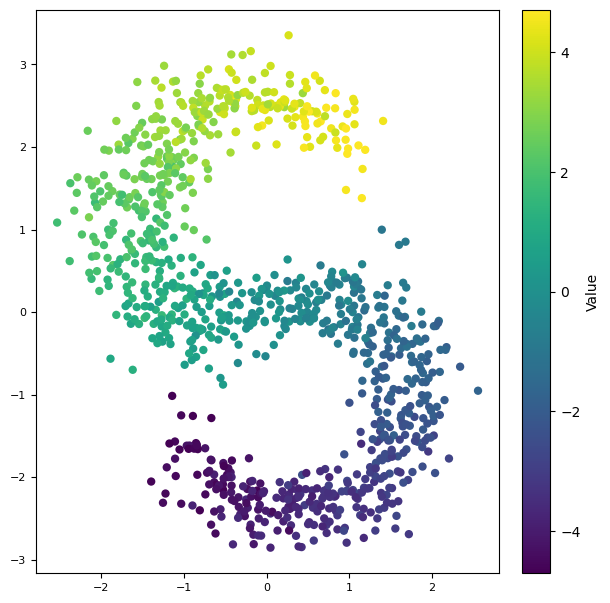

In [5]:
from scripts.plotting import *

plot_2d(X_scipy, t)

In [6]:
X_scipy.shape

(1000, 2)

In [7]:
from scripts.TPS import *
tps = ThinPlateSpline(X_scipy, n_control_points=1000)
tps.fit(X, lambda_reg=100)

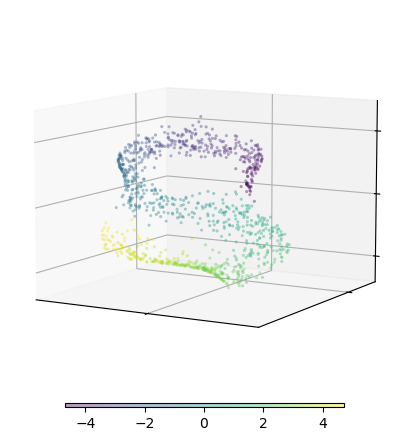

In [8]:
plot_3d(tps.predict(X_scipy), t)

In [9]:
jacobians_f = tps.compute_tps_jacobians(X_scipy)
jacobians_f.shape

(1000, 3, 2)

In [10]:
def total_loss(X_flat, D, tps, X):
    X = X_flat.reshape((-1, 2))
    X_smoothed = tps.predict(X_2d)
    dist_X = squareform(pdist(X_smoothed, metric='euclidean'))
    loss = np.sum((dist_X - D) ** 2) / 2  # Divide by 2 to avoid double counting
    return loss2

# Total gradient: gradient of L_total = grad(L1) + λ * grad(L2)
def total_gradient(X_flat, D, tps, X, lam):
    # Reshape the 1D array back into 2D points
    X_2d = X_flat.reshape((-1, 2))
    X_smoothed = tps.predict(X_2d)
    dist_X = squareform(pdist(X_smoothed, metric='euclidean'))
    dist = (dist_X - D)
    jacobians_f = tps.compute_tps_jacobians(X_2d)
    grad = 2 * np.einsum("nai,na -> ni", jacobians_f, (X - X_smoothed), optimize=True)
    
    # Gradient for L2    
    # Compute pairwise differences and distances
    diff = X_2d[:, np.newaxis, :] - X_2d[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    
    # Avoid division by zero
    dist_safe = np.maximum(dist, 1e-8)
    
    # Compute gradient
    scaling = 2 * (dist - D) / dist_safe
    grad2 = np.sum(scaling[:, :, np.newaxis] * diff, axis=1)
    
    # Total gradient is the sum of the two (with L2 weighted by lam)
    total_grad = grad1 + lam * grad2
    
    # Return as a flattened array (since the optimizer expects 1D arrays)
    return total_grad.flatten()

# Optimization function that minimizes the total loss
def optimize_total(tps, X_2d, X, D, lam, disp=False):
    # X here is your initial guess for the 2D points, of shape (n, 2)
    X_flat = X_2d.flatten()  # Flatten for the optimizer
    result = minimize(
        fun=total_loss,
        x0=X_flat,
        jac=total_gradient,
        args=(D, tps, X, lam),
        method='L-BFGS-B',
        options={"disp": disp}
    )
    # Reshape the optimized variable back into (n, 2)
    X_optimized = result.x.reshape((-1, 2))
    return X_optimized, result

# Example usage:
# Suppose tps and tps_vf are your TPS objects,
# X is your original set of points (n, 2),
# Y is the target set for the second term (n, 2),
# and lam is your weighting parameter.
#
lam = 0.01
%time X_optimized, optimization_result = optimize_total(tps, X_scipy, X, geodesic_distances, lam, disp=True)

TypeError: total_loss() takes 4 positional arguments but 5 were given

In [11]:
# Total loss function: L_total = L1 + λ * L2
def total_loss(X_flat, D, tps, X, lam):
    # Reshape the 1D array into 2D points (n, 2)
    X_2d = X_flat.reshape((-1, 2))
    X_smoothed = tps.predict(X_2d)
    loss1 = np.sum((X - X_smoothed) ** 2)
    
    energy = tps.lambda_reg * np.sum(tps.weights ** 2)
    
    # L2: Loss of MDS
    X = X_flat.reshape((-1, 2))
    dist_X = squareform(pdist(X, metric='euclidean'))
    loss2 = np.sum((dist_X - D) ** 2) / 2  # Divide by 2 to avoid double counting
    return loss1 + energy + lam * loss2

# Total gradient: gradient of L_total = grad(L1) + λ * grad(L2)
def total_gradient(X_flat, D, tps, X, lam):
    # Reshape the 1D array back into 2D points
    X_2d = X_flat.reshape((-1, 2))
    
    # Gradient for L1
    X_smoothed = tps.predict(X_2d)
    jacobians_f = tps.compute_tps_jacobians(X_2d)
    grad1 = -2 * np.einsum("nai,na -> ni", jacobians_f, (X - X_smoothed), optimize=True)
    
    # Gradient for L2    
    # Compute pairwise differences and distances
    diff = X_2d[:, np.newaxis, :] - X_2d[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    
    # Avoid division by zero
    dist_safe = np.maximum(dist, 1e-8)
    
    # Compute gradient
    scaling = 2 * (dist - D) / dist_safe
    grad2 = np.sum(scaling[:, :, np.newaxis] * diff, axis=1)
    
    # Total gradient is the sum of the two (with L2 weighted by lam)
    total_grad = grad1 + lam * grad2
    
    # Return as a flattened array (since the optimizer expects 1D arrays)
    return total_grad.flatten()

# Optimization function that minimizes the total loss
def optimize_total(tps, X_2d, X, D, lam, disp=False):
    # X here is your initial guess for the 2D points, of shape (n, 2)
    X_flat = X_2d.flatten()  # Flatten for the optimizer
    result = minimize(
        fun=total_loss,
        x0=X_flat,
        jac=total_gradient,
        args=(D, tps, X, lam),
        method='L-BFGS-B',
        options={"disp": disp}
    )
    # Reshape the optimized variable back into (n, 2)
    X_optimized = result.x.reshape((-1, 2))
    return X_optimized, result

# Example usage:
# Suppose tps and tps_vf are your TPS objects,
# X is your original set of points (n, 2),
# Y is the target set for the second term (n, 2),
# and lam is your weighting parameter.
#
lam = 0.01
%time X_optimized, optimization_result = optimize_total(tps, X_scipy, X, geodesic_distances, lam, disp=True)

CPU times: user 2.41 s, sys: 418 ms, total: 2.83 s
Wall time: 2.74 s


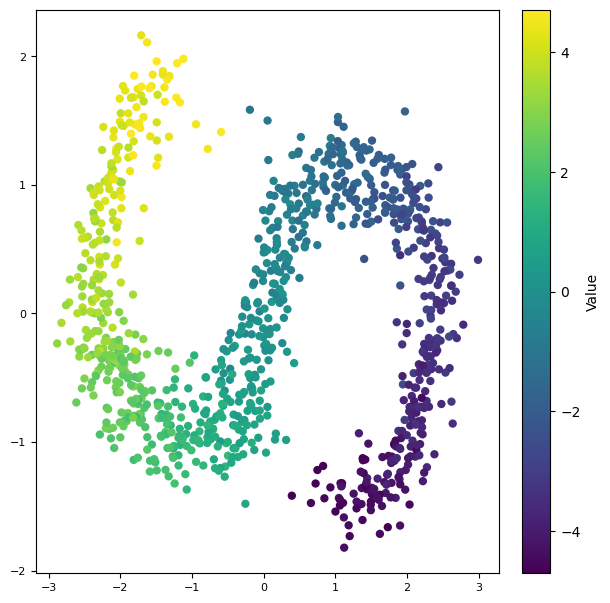

Iteration 1


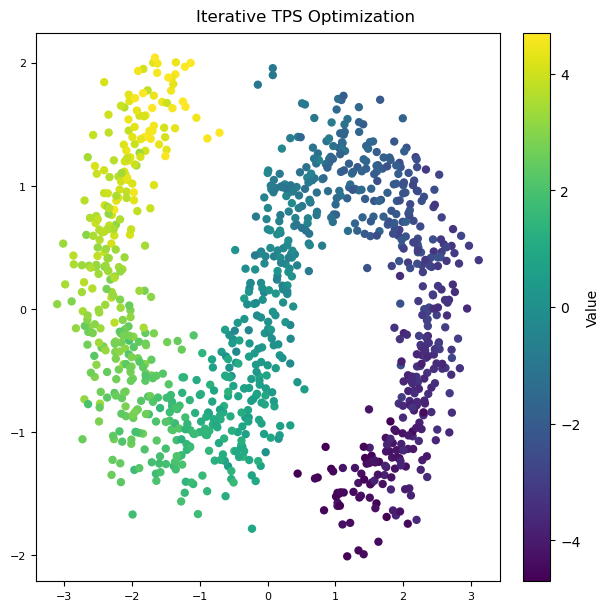

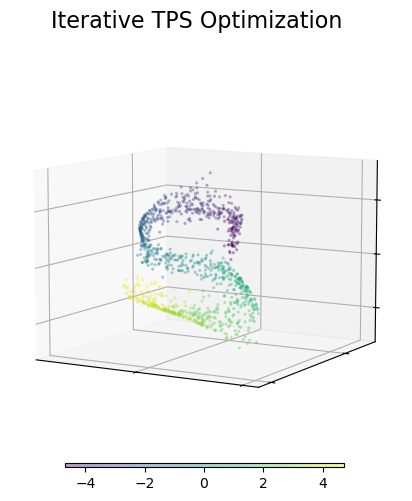

Iteration 2


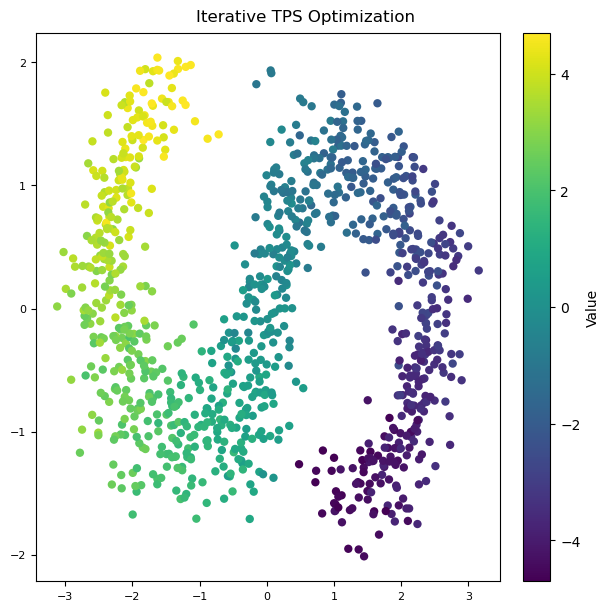

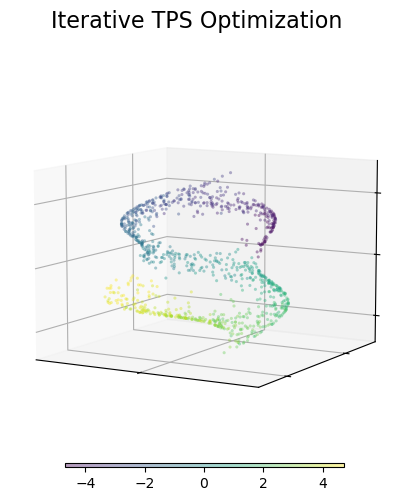

Iteration 3


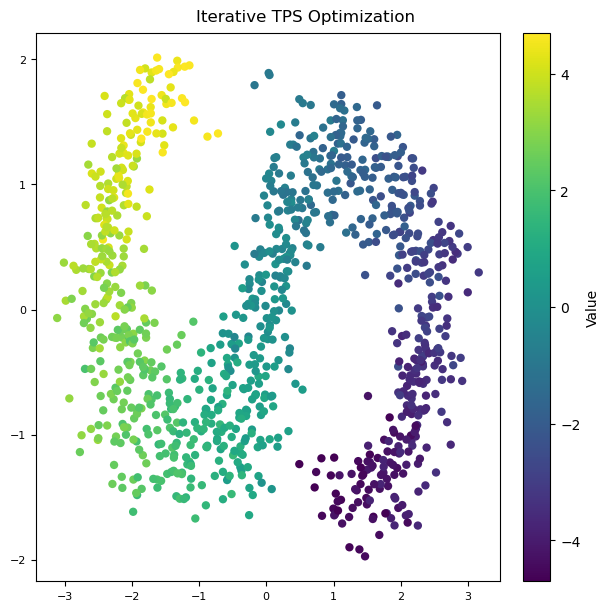

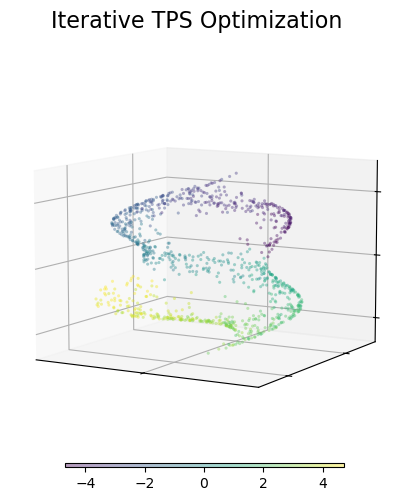

Iteration 4


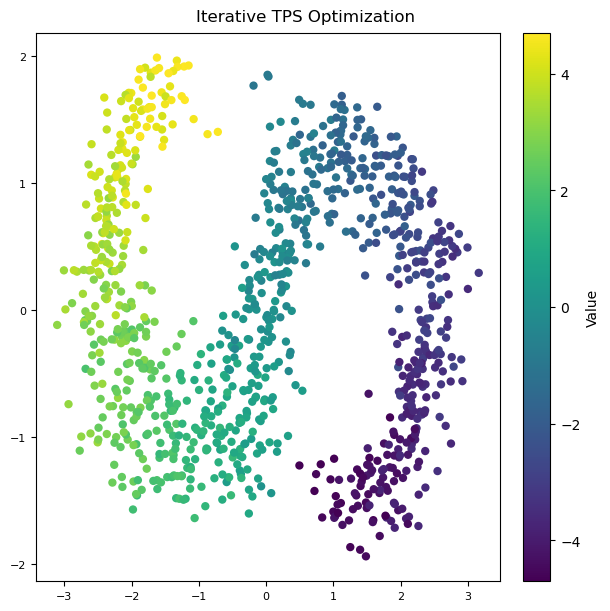

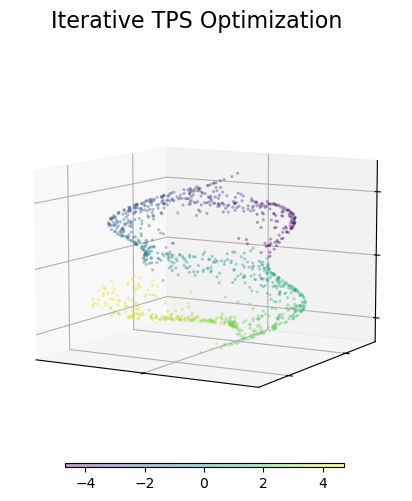

Iteration 5


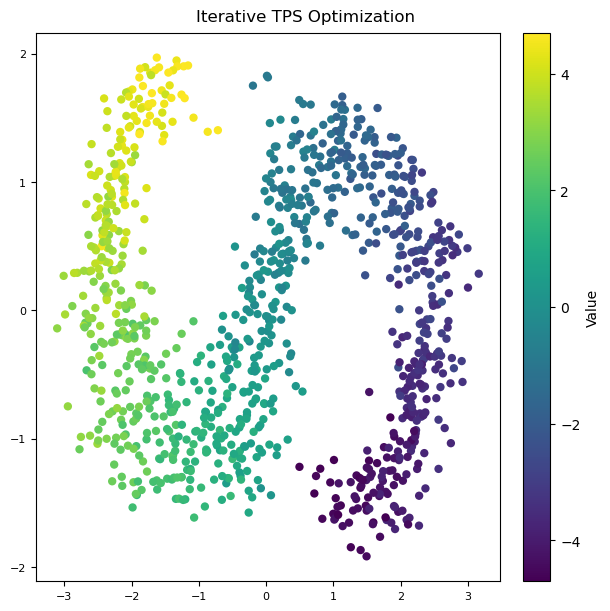

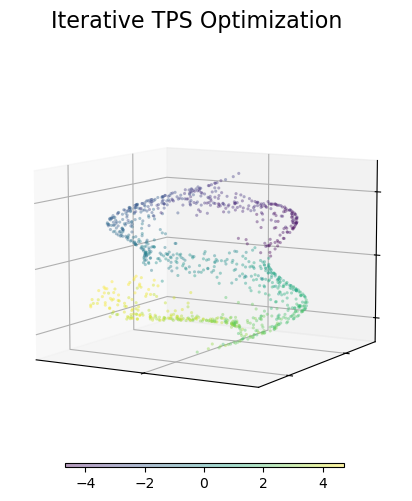

Iteration 6


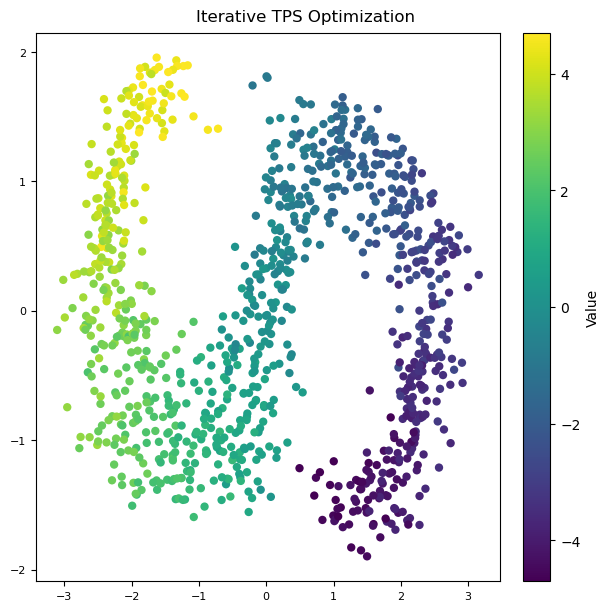

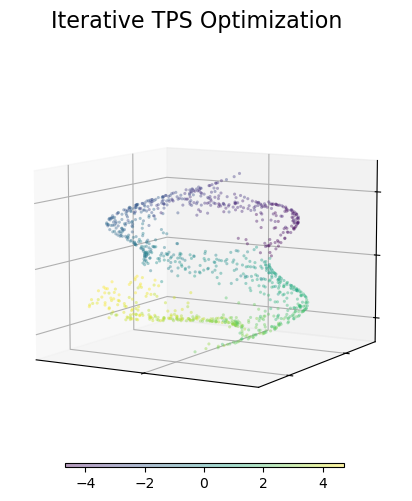

Iteration 7


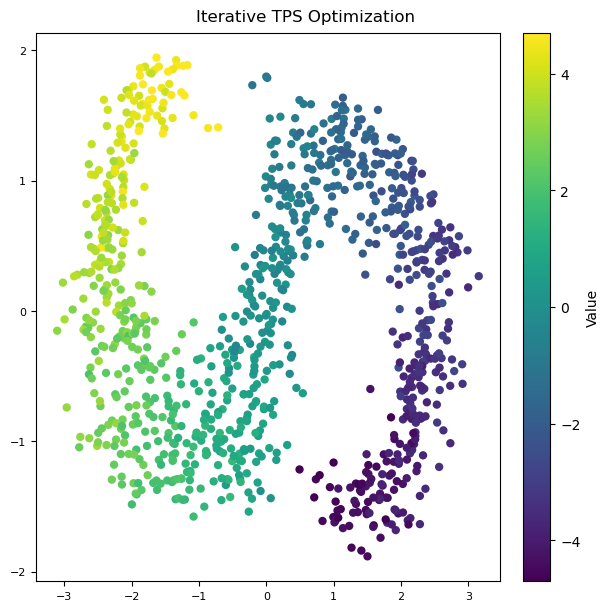

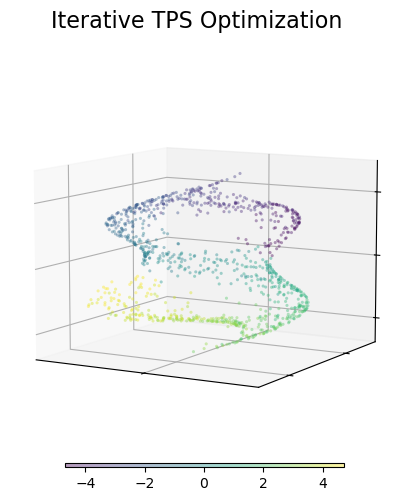

Iteration 8


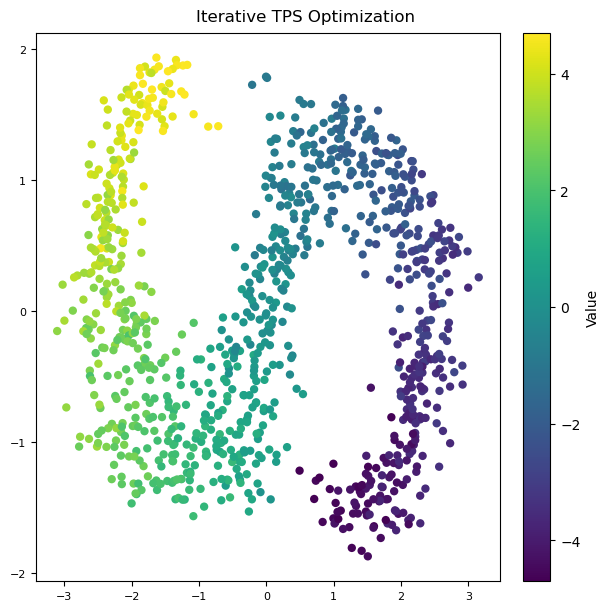

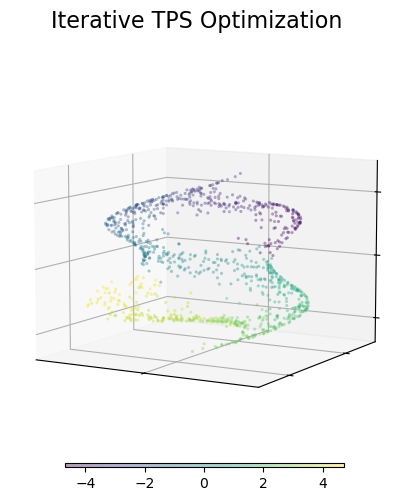

Iteration 9


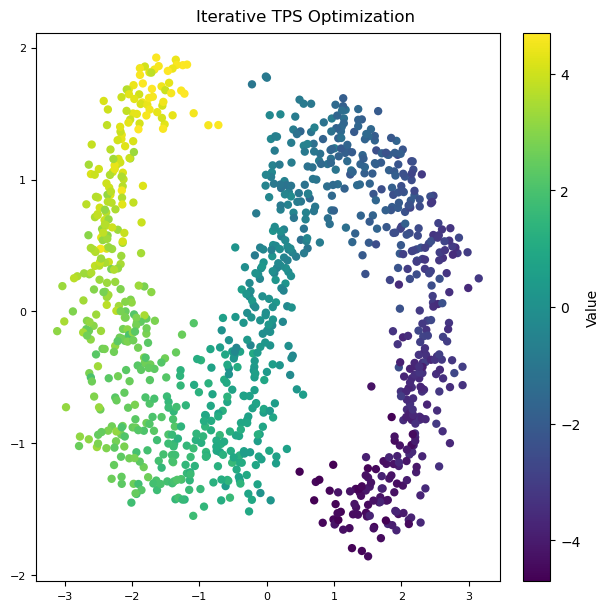

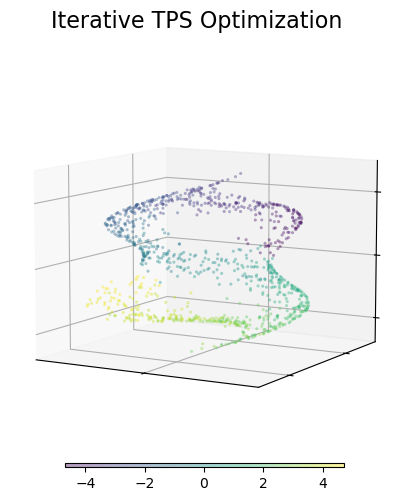

Iteration 10


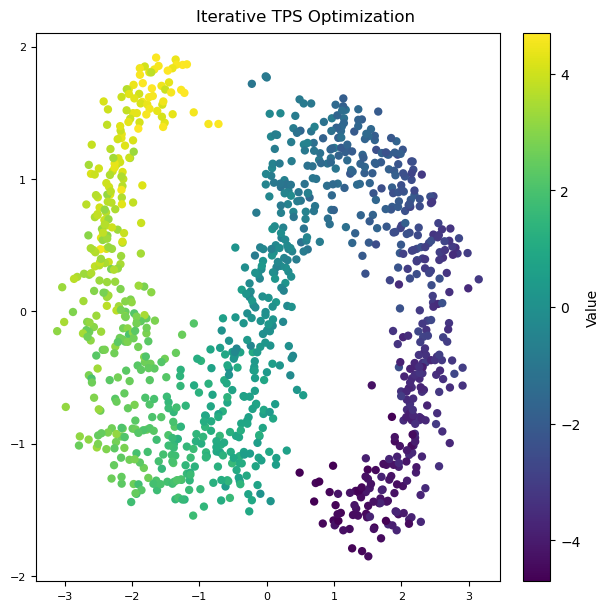

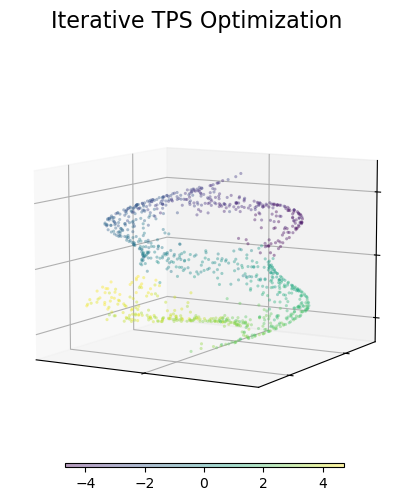

Iteration 11


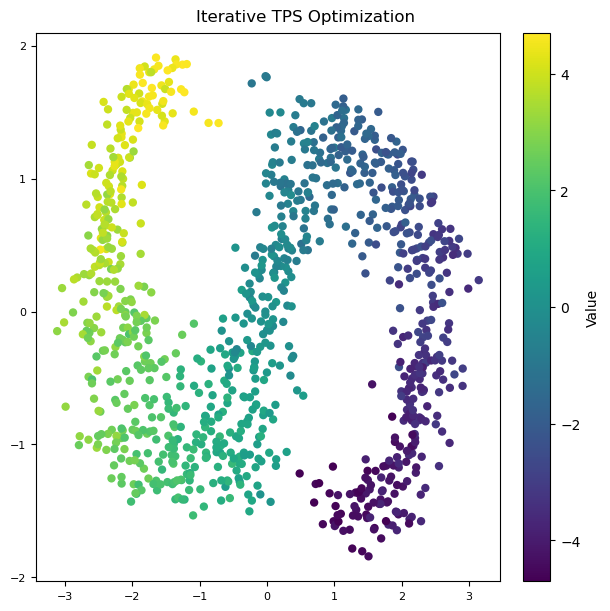

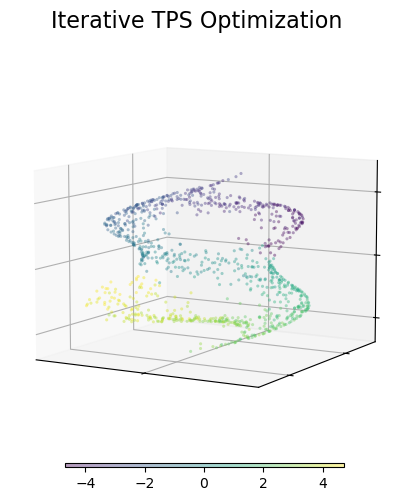

Iteration 12


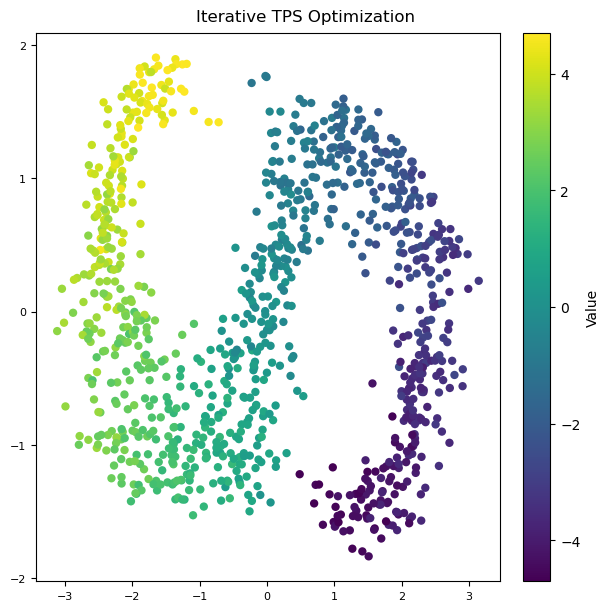

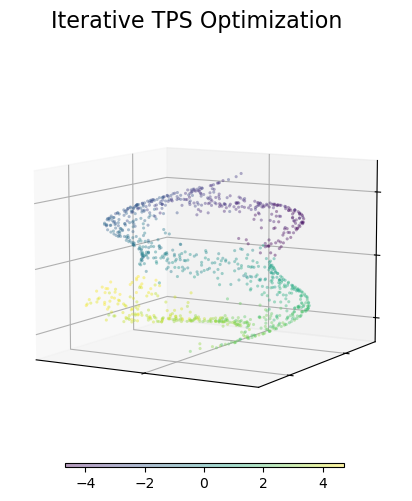

Iteration 13


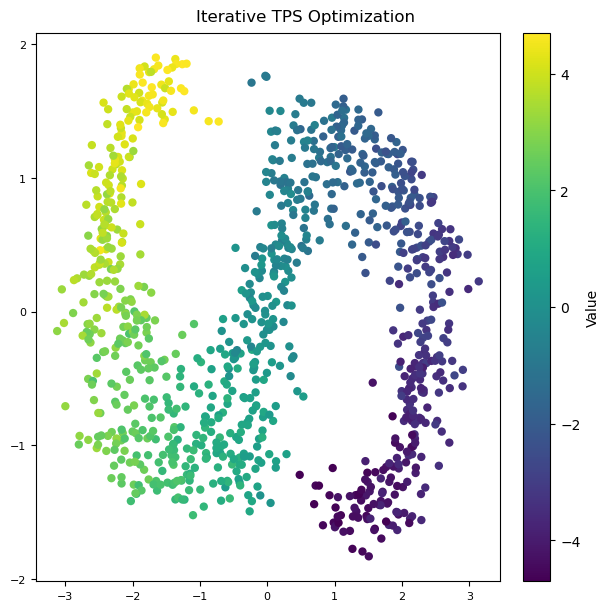

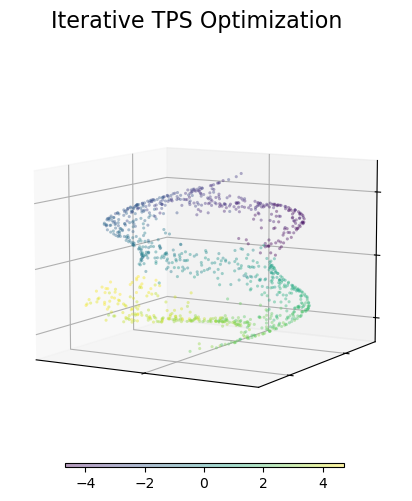

Iteration 14


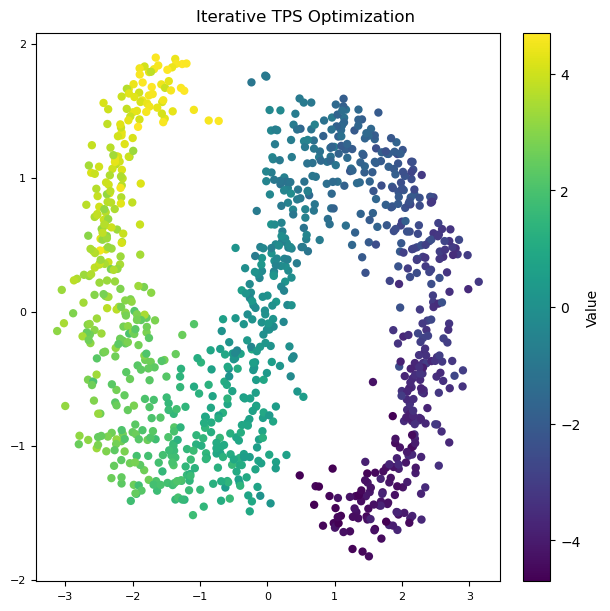

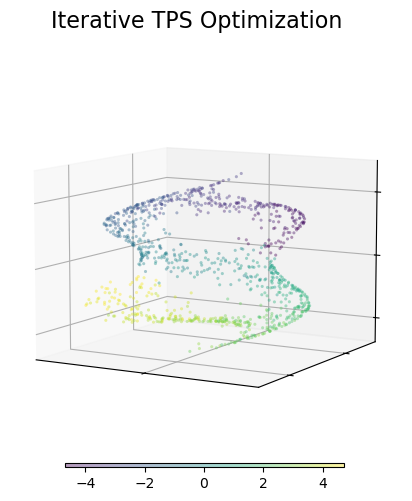

Iteration 15


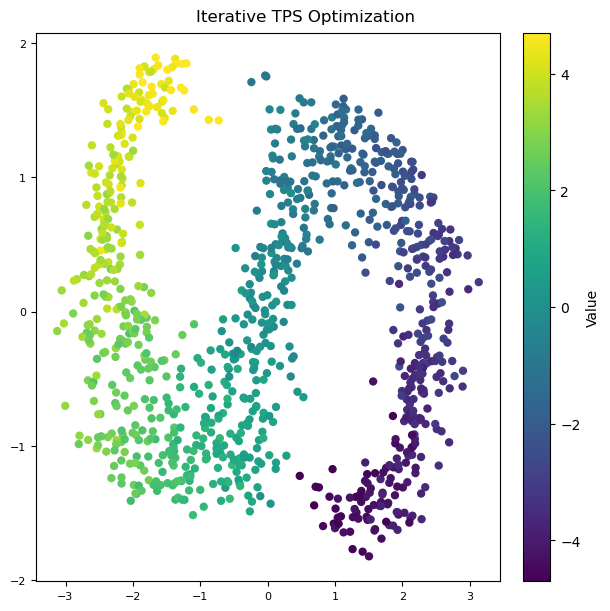

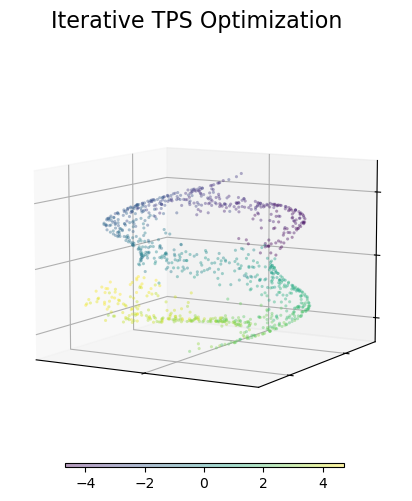

Iteration 16


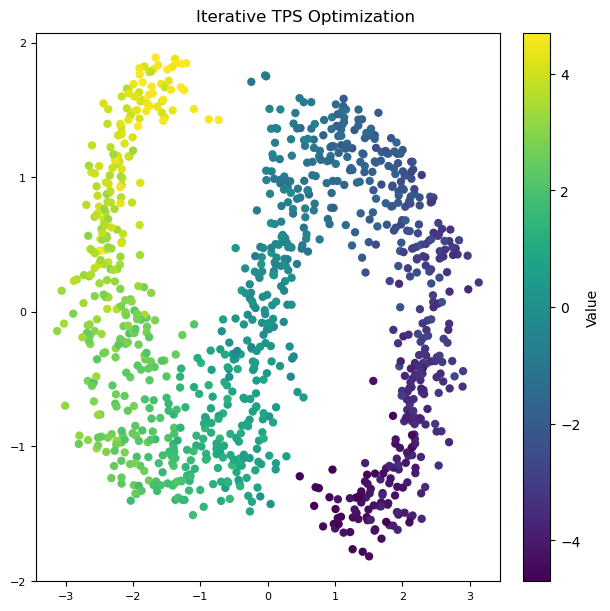

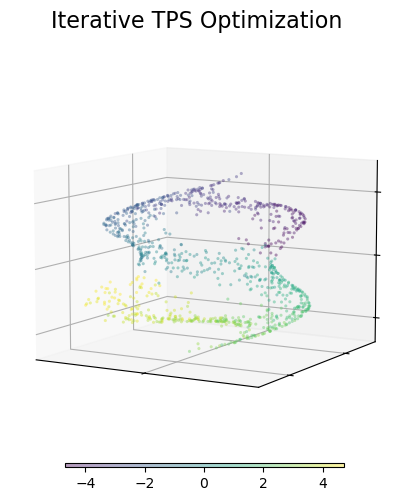

Iteration 17


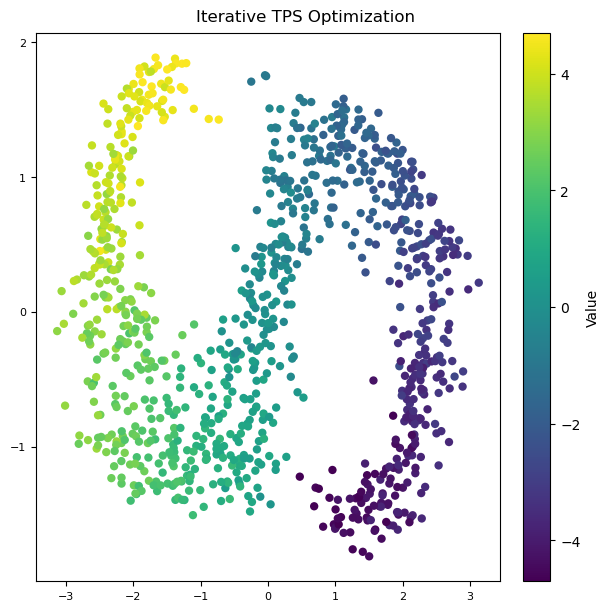

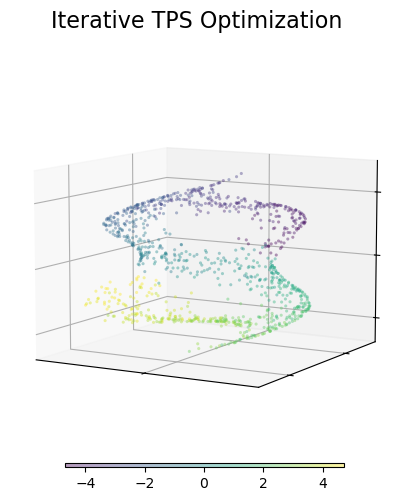

Iteration 18


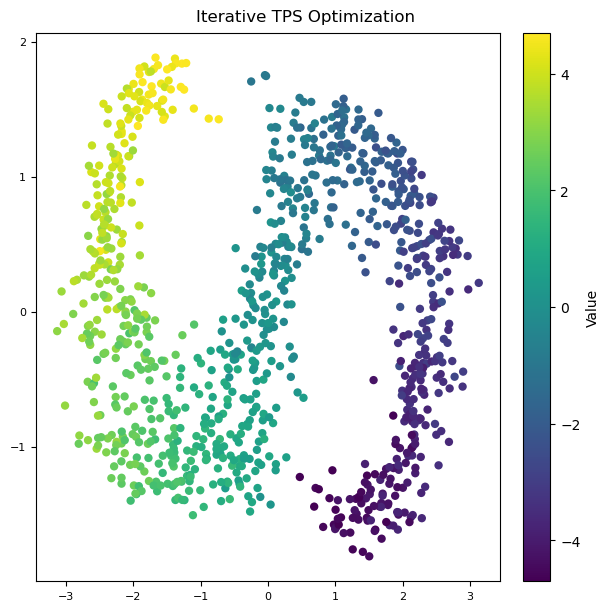

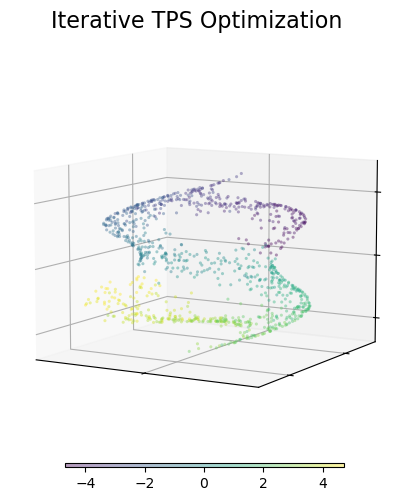

Iteration 19


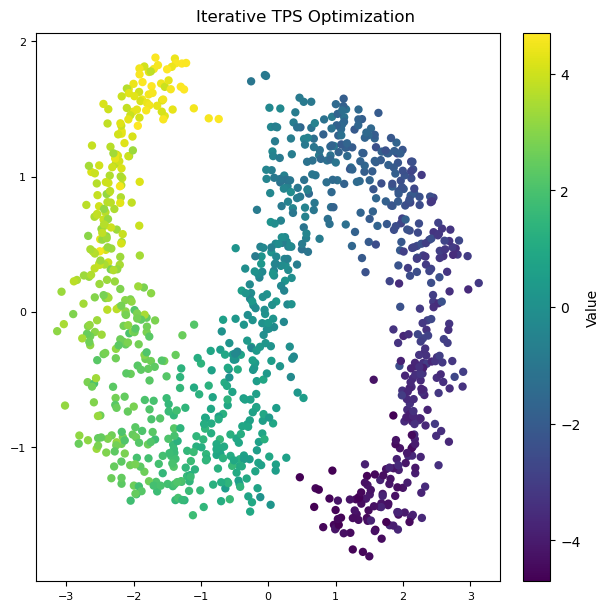

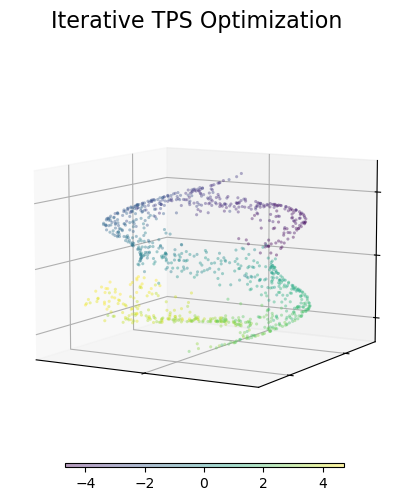

Iteration 20


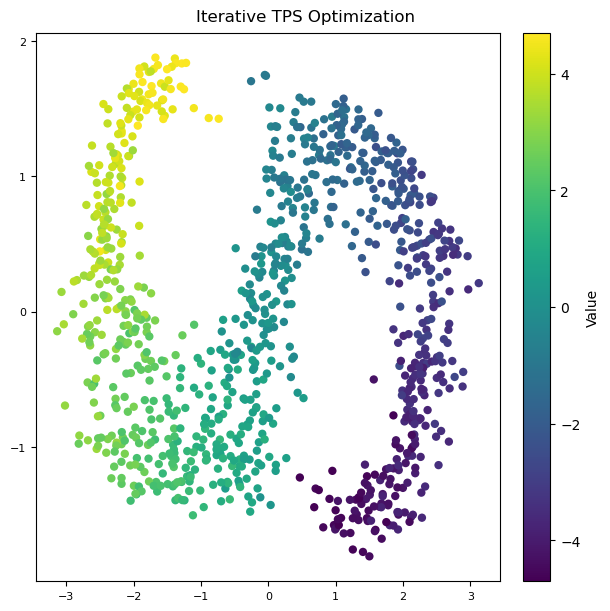

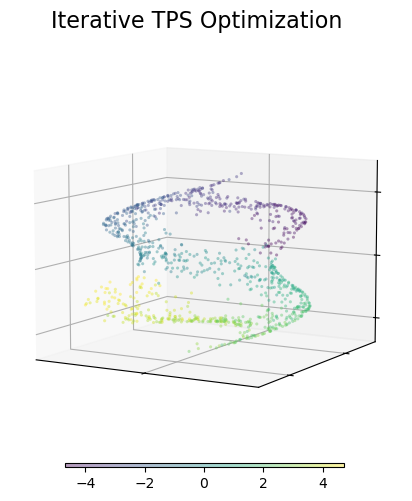

In [12]:
from sklearn.manifold import Isomap

isomap = Isomap(n_components=2, n_neighbors=20)
X_2d = isomap.fit_transform(X)
plot_2d(X_2d, t)
geodesic_distances = isomap.dist_matrix_

lam = 0.01
num_iterations = 20
for i in range(num_iterations):
    print(f"Iteration {i+1}")

    # Step 2: Fit the thin-plate spline (TPS)
    tps = ThinPlateSpline(X_2d, n_control_points=1000)
    tps.fit(X, lambda_reg=100)
    X_2d, optimization_result = optimize_total(tps, X_2d, X, geodesic_distances, lam, disp=False)

    # Final visualization
    plot_2d(X_2d, t, "Iterative TPS Optimization")
    plot_3d(tps.predict(X_2d), t, "Iterative TPS Optimization")

In [13]:
from sklearn.neighbors import NearestNeighbors
from scipy.sparse.csgraph import shortest_path

def compute_geodesic_distances(X, n_neighbors=5, metric='euclidean'):
    """
    Compute the geodesic distance matrix for a dataset using k-nearest neighbors.
    
    Parameters:
        X          : (n_samples, n_features) input data matrix.
        n_neighbors: Number of nearest neighbors for the graph.
        metric     : Distance metric for nearest neighbors ('euclidean' by default).
        
    Returns:
        geodesic_dist: (n_samples, n_samples) geodesic distance matrix.
    """
    # Step 1: Find k-nearest neighbors and construct a distance graph
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, metric=metric).fit(X)
    distance_graph = nbrs.kneighbors_graph(mode='distance')

    # Step 2: Compute shortest paths (geodesic distances) using Floyd-Warshall or Dijkstra
    geodesic_dist = shortest_path(distance_graph, method='auto', directed=False)
    
    return geodesic_dist


geodesic_distances = compute_geodesic_distances(X, n_neighbors=15)

print("Geodesic Distance Matrix:")
print(geodesic_distances)

Geodesic Distance Matrix:
[[0.         2.2234323  1.11973274 ... 3.83621825 2.61676143 4.2475512 ]
 [2.2234323  0.         2.36866203 ... 3.1027142  2.71922102 2.10327663]
 [1.11973274 2.36866203 0.         ... 4.21415612 1.92358687 4.39278094]
 ...
 [3.83621825 3.1027142  4.21415612 ... 0.         5.44071071 2.37273997]
 [2.61676143 2.71922102 1.92358687 ... 5.44071071 0.         3.56755137]
 [4.2475512  2.10327663 4.39278094 ... 2.37273997 3.56755137 0.        ]]
